In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import RobustScaler,StandardScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score 
import warnings
warnings.filterwarnings("ignore")


In [2]:
df=pd.read_csv("/kaggle/input/salaly-prediction-for-beginer/Salary Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


#EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [4]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [7]:
df.duplicated().sum()

49

In [8]:
df.drop_duplicates(keep="first",inplace=True)

In [9]:
df.duplicated().sum()

0

In [10]:
df.describe()

,Age,Years of Experience,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


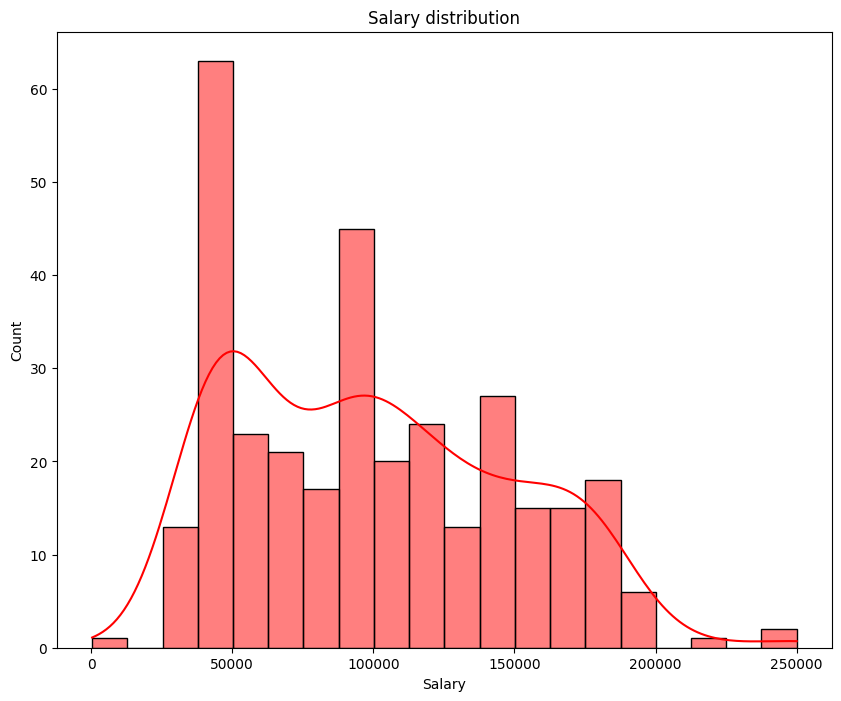

In [11]:
plt.figure(figsize=(10, 8))
sns.histplot(df["Salary"], kde=True, bins=20, color="red", edgecolor="black")
plt.title("Salary distribution")
plt.show()

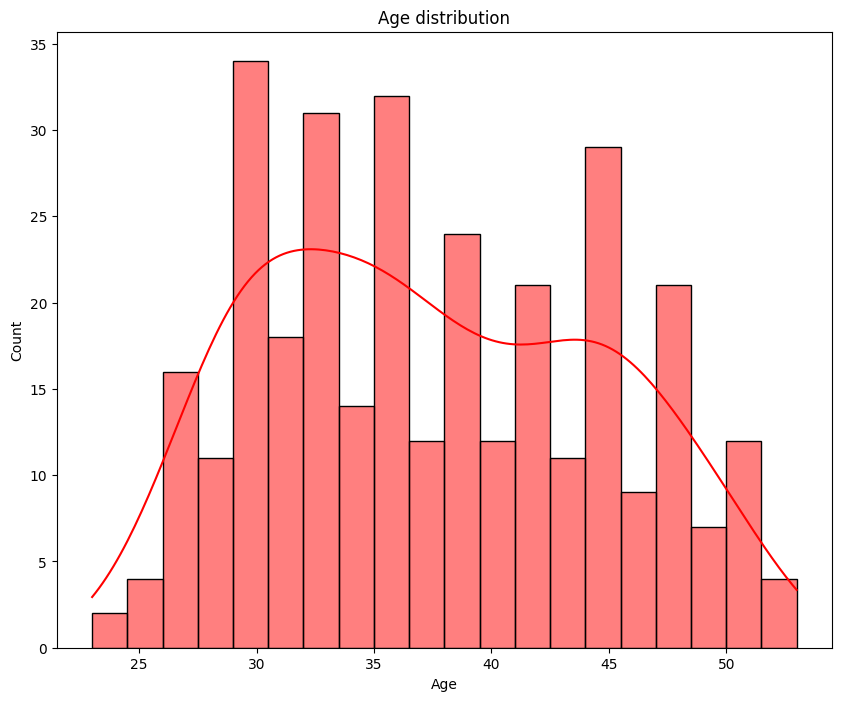

In [12]:
plt.figure(figsize=(10, 8))
sns.histplot(df["Age"], kde=True, bins=20, color="red", edgecolor="black")
plt.title("Age distribution")
plt.show()

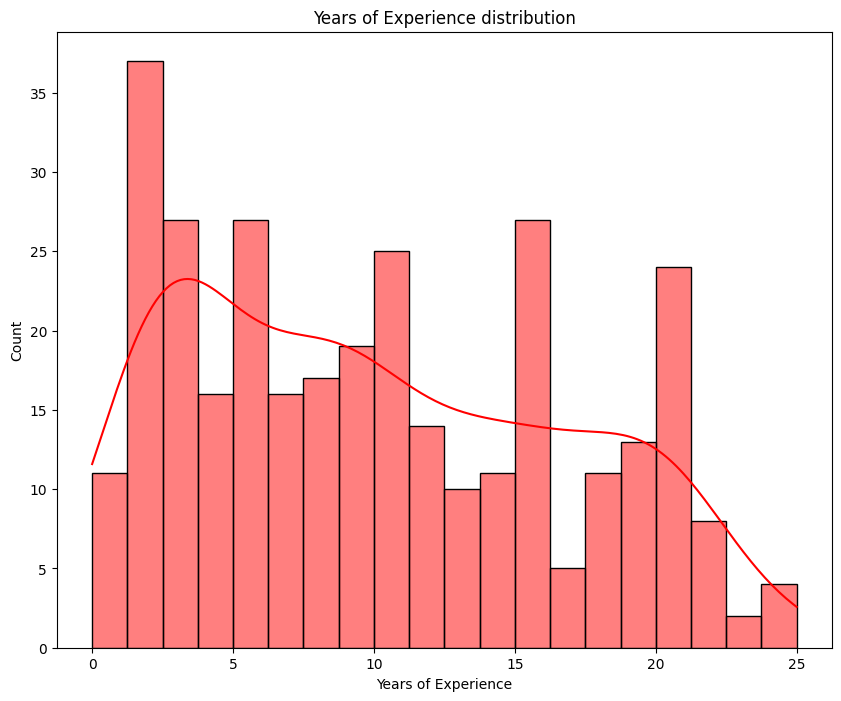

In [13]:
plt.figure(figsize=(10, 8))
sns.histplot(df["Years of Experience"], kde=True, bins=20, color="red", edgecolor="black")
plt.title("Years of Experience distribution")
plt.show()

In [14]:
df["Age"]=df["Age"].astype(int)

In [15]:
df["Age"].dtype

dtype('int64')

In [16]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28,Female,Master's,Data Analyst,3.0,65000.0
2,45,Male,PhD,Senior Manager,15.0,150000.0
3,36,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52,Male,Master's,Director,20.0,200000.0


In [17]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
348,28,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44,Female,PhD,Senior Data Scientist,16.0,160000.0
351,31,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0
371,43,Male,Master's,Director of Operations,19.0,170000.0


#preprocession

In [18]:
df["Age"]=StandardScaler().fit_transform(df[["Age"]])

In [19]:
df["Years of Experience"]=StandardScaler().fit_transform(df[["Years of Experience"]])

In [20]:
df["Salary"]=RobustScaler().fit_transform(df[["Salary"]])

In [21]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,-0.750231,Male,Bachelor's,Software Engineer,-0.761821,-0.058824
1,-1.307742,Female,Master's,Data Analyst,-1.063017,-0.352941
2,1.061680,Male,PhD,Senior Manager,0.744158,0.647059
3,-0.192720,Female,Bachelor's,Sales Associate,-0.460625,-0.411765
4,2.037324,Male,Master's,Director,1.497148,1.235294


In [22]:
df["Gender"]= OneHotEncoder(drop='first', sparse_output=False).fit_transform(df[['Gender']])


In [23]:
df["Education Level"]= LabelEncoder().fit_transform(df[['Education Level']])


In [24]:
df=df.drop(columns=["Job Title"],axis=1)

In [25]:
x=df.drop(columns=["Salary"],axis=1)
x

,Age,Gender,Education Level,Years of Experience
0,-0.750231,1.0,0,-0.761821
1,-1.307742,0.0,1,-1.063017
2,1.061680,1.0,2,0.744158
3,-0.192720,0.0,0,-0.460625
4,2.037324,1.0,1,1.497148
...,...,...,...,...
348,-1.307742,0.0,0,-1.364212
349,-0.192720,1.0,0,-0.310027
350,0.922302,0.0,2,0.894756
351,-0.889609,1.0,0,-1.063017


In [26]:
y=df[["Salary"]]
y

,Salary
0,-0.058824
1,-0.352941
2,0.647059
3,-0.411765
4,1.235294
...,...
348,-0.705882
349,0.176471
350,0.764706
351,-0.470588


In [27]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=.1,shuffle=True,random_state=42)

In [28]:
lr_model=LinearRegression()
lr_model.fit(train_x,train_y)

LinearRegression()

In [29]:
lr_model.score(train_x,train_y)

0.8946363154629938

In [30]:
y_pred = lr_model.predict(test_x)

In [31]:
print(mean_squared_error(test_y, y_pred))

0.03321538092915918


In [32]:
print(r2_score(test_y, y_pred))

0.8939863912803896


In [33]:
import joblib

In [34]:
joblib.dump(lr_model,"LR Model.pkl")

['LR Model.pkl']